In [143]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
import importlib
import main_functions
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

importlib.reload(main_functions) 
from main_functions import *

### Применим методы машинного обучения, чтобы улучшить стратегию, которую мы отобрали ранее. Мы будем использовать стратегии под номером 1.
1) Бычье Поглощение - 30 мин, N=25

In [145]:
sber = pd.read_csv(r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\SBER.txt')
with open(r'C:\Users\user\Desktop\Проект 1 года обучения\Повышение эффективности с помощью ML\Результаты паттернов\results_strategies_2candle.pkl', 'rb') as file:
    sber_result = pickle.load(file)
display(sber_result.head(3))
display(sber.head(2))

,ticker,strategy name,period,N,count of trades,profit factor,total percent return,R2,win_rate,mean profit (%),...,capital curve net,capital curve without commission,profit percent net,percent profit without commission,profit factor rank,R2 rank,profit/loss ratio rank,max drawdown rank,best model,buy and hold (%)
0,PLZL,push_long,4h,7,767,1.231,238.37,0.77,0.47,2.4,...,time_N 2009-01-14 08:00:00 95709.000000 20...,time_N 2009-01-14 08:00:00 9.587500e+04 200...,time_N 2009-01-14 08:00:00 -0.04291 2009-01-...,time_N 2009-01-14 08:00:00 -0.04125 2009-01-...,2.0,4.0,4.0,3.0,13.0,2645.5
1,PLZL,separation,D,3,782,1.254,363.68,0.73,0.48,2.9,...,time_N 2009-01-13 98560.000000 2009-01-19 ...,time_N 2009-01-13 9.872900e+04 2009-01-19 ...,time_N 2009-01-13 -0.01440 2009-01-19 0.0...,time_N 2009-01-13 -0.01271 2009-01-19 0.0...,3.0,2.5,3.0,2.0,10.5,2645.5
2,SBER,separation,D,3,788,1.277,570.05,0.73,0.52,2.8,...,time_N 2009-01-27 94516.000000 2009-02-09 ...,time_N 2009-01-27 9.468100e+04 2009-02-09 ...,time_N 2009-01-27 -0.05484 2009-02-09 0.1...,time_N 2009-01-27 -0.05319 2009-02-09 0.2...,4.0,2.5,1.0,1.0,8.5,NaN


,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,SBER,1,20090111,103000,23.30,23.30,22.99,23.01,666517
1,SBER,1,20090111,103100,23.01,23.08,22.98,23.02,199410


In [146]:
# Паттерн разделение
def detection_of_separation(data):
    """
    Обнаружение бычьего паттерна "Разделение" (Separating Lines) и генерация торгового сигнала.
    
    Паттерн "Разделение" - это двухсвечная модель продолжения тренда.
    Первая свеча медвежья, вторая свеча бычья. Цены открытия обеих свечей равны
    или очень близки (расхождение не более 5%).
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттерна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'separation'
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'separation'
    
    # Векторизованные вычисления
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    

    # Базовое условие для просвета в облаках
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        ((np.abs(open_N_1 - open_N) / open_N_1) <= 0.05))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data


### Попробуем улучшить сперва стратегию 1.

In [147]:
def preperation_to_modeling(data, period, func, N, profit):
    """Функция предназначена для подготовки датафрейма к дальнейшему моделированию

    Args:
        data (pd.DataFrame): 1-минутный таймфрейм
        period (object): Передаем период из стратегии
        func (function): Какой паттерн проверяем?
        N (int): Сколько следующих свеч удерживаем паттерн?
        profit (pd.Series): Численные результаты торгов

    Returns:
        Подготовленный датафрейм для использования ml
    """
    data_timeframe = good_dataframe(data, period)
    data_with_pattern = func(shift_features_2_candle(data_timeframe))
    
    # Обрезка
    data_with_pattern.loc[len(data_with_pattern) - 51 : len(data_with_pattern), ['pattern', 'signal']] = 0
    data_filter = filter_min_distance(data_with_pattern, 'signal', N)
    data_filter['signal_N-1'] = data_filter['signal'].shift(-1)
    data_filter.loc[data_filter['signal_N-1'] == 0, 'pattern'] = 0
    data_filter.drop(['signal', 'signal_N-1', 'per', 'ticker', 'strategy'], axis=1, inplace=True)
    data_filter.dropna(inplace=True)
    
    # Соединяем доходности
    result = profit.loc[2, 'profit percent net']
    data_filter = data_filter.set_index('time_N')
    final_data = data_filter.join(result).fillna(0)
    final_data = final_data.reset_index()
    final_data['profit_percent_net'] = final_data['profit_percent_net'].shift(-1)
    return final_data

df = preperation_to_modeling(sber, 'D', detection_of_separation, 2, sber_result)

In [148]:
df[df['profit_percent_net'] != 0]

,time_N,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N-1,pattern,profit_percent_net
10,2009-01-26,15.48,15.80,17.10,15.20,14.69,14.15,17.17,16.04,386564746,244905202.0,2009-01-23,1,-0.05484
19,2009-02-06,15.14,15.06,15.58,14.87,14.87,14.82,15.67,15.35,260169365,183755601.0,2009-02-05,1,0.19839
28,2009-02-19,14.71,15.32,15.18,14.63,14.58,13.50,15.64,15.74,438492550,670658560.0,2009-02-18,1,-0.01267
43,2009-03-16,16.92,17.29,18.30,16.90,16.85,16.84,18.32,17.69,619757443,512761725.0,2009-03-13,1,0.29341
46,2009-03-19,21.71,20.90,24.05,20.47,21.26,20.21,25.03,22.40,1276125753,945487092.0,2009-03-18,1,-0.03127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4327,2026-01-06,298.92,299.99,299.08,298.78,298.20,296.21,299.94,300.12,6964442,15363736.0,2026-01-05,1,0.00621
4332,2026-01-14,297.34,299.20,298.58,297.23,296.02,296.61,299.78,301.04,18333345,18375242.0,2026-01-13,1,0.00794
4336,2026-01-18,301.28,301.67,301.86,301.28,301.10,301.00,301.89,301.89,860536,1061595.0,2026-01-17,1,0.01365
4341,2026-01-23,305.97,306.64,306.88,306.22,305.30,304.22,307.36,307.00,17070878,23317330.0,2026-01-22,1,-0.01358


### Создаем признаки

In [149]:
# Признаки по дате и времени
def data_time_features(data):
    """Функция для создания временных признаков

    Args:
        data (pd.DataFrame): Датафрейм с разметкой данных

    Returns:
       data (pd.DataFrame): Новый датафрейм с временными признаками
    """
    data = data.copy()
    data['time_N'] = pd.to_datetime(data['time_N'])
    data['months_N'] = data['time_N'].dt.month
    data['days_N'] = data['time_N'].dt.day
    data['hours_N'] = data['time_N'].dt.hour
    
    return data

In [150]:
# Признаки по каждой свече
def data_one_candle_features_1(data):
    """
    Расчет характеристик свечей для ML-моделей.
    
    Признаки для текущей свечи (N) и предыдущей (N-1):
        - has_body_N, has_body_N-1: наличие тела свечи
        - ratio_body_to_all_candle_N: отношение тела к полному диапазону (High-Low)
        - ratio_up_shadow_to_body_N: отношение верхней тени к телу
        - ratio_low_shadow_to_body_N: отношение нижней тени к телу
        - ratio_up_to_low_shadow_N: соотношение верхней и нижней теней
        - has_both_shadows_N: наличие обеих теней
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open_N, high_N, low_N, close_N,
                            open_N-1, high_N-1, low_N-1, close_N-1
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные признаки (NaN заменены на 0)"""
    data = data.copy()
    # Отношение тела свечи ко всей свече
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    # есть ли тело и есть ли свеча
    data['has_body_N'] = (body_N > 0).astype('int')
    data['has_body_N-1'] = (body_N_1 > 0).astype('int')
    data['has_full_candle_N'] = (full_candle_N > 0).astype('int')
    data['has_full_candle_N-1'] = (full_candle_N_1 > 0).astype('int')
    
    data['ratio_body_to_all_candle_N'] = np.where(full_candle_N > 0, body_N / full_candle_N, np.nan)
    data['ratio_body_to_all_candle_N-1'] = np.where(full_candle_N_1 > 0, body_N_1 / full_candle_N_1, np.nan)
    
    # Отношение верхней тени к телу свечи
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    data['ratio_up_shadow_to_body_N'] = np.where(body_N > 0, up_shadow_N / body_N, np.nan)
    data['ratio_up_shadow_to_body_N-1'] = np.where(body_N_1 > 0, up_shadow_N_1 / body_N_1, np.nan)

    # Отношение нижней тени к телу свечи
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    data['ratio_low_shadow_to_body_N'] = np.where(body_N > 0, low_shadow_N / body_N, np.nan)
    data['ratio_low_shadow_to_body_N-1'] = np.where(body_N_1 > 0, low_shadow_N_1 / body_N_1, np.nan)

    # Отношение верхней тени к нижней тени
    data['ratio_up_to_low_shadow_N'] = np.where((low_shadow_N > 0) & (up_shadow_N > 0), up_shadow_N / low_shadow_N, np.nan)
    data['ratio_up_to_low_shadow_N-1'] = np.where((low_shadow_N_1 > 0) & (up_shadow_N_1 > 0), up_shadow_N_1 / low_shadow_N_1, np.nan)

    # Добавляем бинарный признак: есть ли обе тени
    data['has_both_shadows_N'] = ((low_shadow_N > 0) & (up_shadow_N > 0)).astype('int')
    data['has_both_shadows_N-1'] = ((low_shadow_N_1 > 0) & (up_shadow_N_1 > 0)).astype('int')
    
    data = data.fillna(0)

    
    return data

In [151]:
def data_one_candle_features_2(data):
    """Расчет ATR-нормированных признаков свечей.
    
    Признаки (нормированы на ATR):
        - body_ATR_N, body_ATR_N-1: размер тела свечи
        - full_candle_ATR_N, full_candle_ATR_N-1: полный диапазон High-Low
        - up_shadow_ATR_N, up_shadow_ATR_N-1: верхняя тень
        - low_shadow_ATR_N, low_shadow_ATR_N-1: нижняя тень
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open_N, high_N, low_N, close_N,
                            open_N-1, high_N-1, low_N-1, close_N-1
    
    Returns:
        pd.DataFrame: Отфильтрованный DataFrame (удалены строки без ATR) с добавленными признаками"""
    
    data = data.copy()
    def ATR(data, period=14):
        high_low = data['high_N'] - data['low_N']
        high_close_prev = np.abs(data['high_N'] - data['close_N'].shift(1))
        low_close_prev = np.abs(data['low_N'] - data['close_N'].shift(1))
    
        TR = np.maximum(high_low, np.maximum(high_close_prev, low_close_prev))
        ATR = TR.rolling(period).mean()
    
        return ATR
    
    atr = ATR(data).shift(1)
    valid_mask = ~atr.isna()
    data = data[valid_mask]
    atr = atr[valid_mask]
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    atr_safe = np.where(atr != 0, atr, 10e-8 )
    
    # Тело свечи / ATR
    data['body_ATR_N'] = body_N / atr_safe
    data['body_ATR_N-1'] = body_N_1 / atr_safe
    
    # Вся свеча / ATR
    data['full_candle_ATR_N'] = full_candle_N / atr_safe
    data['full_candle_ATR_N-1'] = full_candle_N_1 / atr_safe
    
    # Верхняя тень / ATR
    data['up_shadow_ATR_N'] = up_shadow_N / atr_safe
    data['up_shadow_ATR_N-1'] = up_shadow_N_1 / atr_safe
    
    # Нижняя тень / ATR
    data['low_shadow_ATR_N'] = low_shadow_N / atr_safe
    data['low_shadow_ATR_N-1'] = low_shadow_N_1 / atr_safe
    
    return data

In [152]:
def data_two_candles_features(data):
    """
    Расчет межсвечных отношений для двухсвечных паттернов.
    
    Признаки (текущая свеча N к предыдущей N-1):
        - ratio_body_N_to_N-1: отношение размера тела
        - ratio_full_candle_N_to_N-1: отношение полного диапазона
        - ratio_up_shadow_N_to_N-1: отношение верхней тени
        - ratio_low_shadow_N_to_N-1: отношение нижней тени
    
    Бинарные признаки:
        - has_up_shadow_N, has_up_shadow_N-1: наличие верхней тени
        - has_low_shadow_N, has_low_shadow_N-1: наличие нижней тени
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open_N, high_N, low_N, close_N,
                            open_N-1, high_N-1, low_N-1, close_N-1
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные признаки (NaN заменены на 0)
    """
    data = data.copy()
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    
    data['ratio_body_N_to_N-1'] = np.where(body_N_1 > 0, body_N / body_N_1, np.nan)
    data['ratio_full_candle_N_to_N-1'] = np.where(full_candle_N_1 > 0, full_candle_N / full_candle_N_1, np.nan)
    data['ratio_up_shadow_N_to_N-1'] = np.where(up_shadow_N_1 > 0, up_shadow_N / up_shadow_N_1, np.nan)
    data['ratio_low_shadow_N_to_N-1'] = np.where(low_shadow_N_1 > 0, low_shadow_N / low_shadow_N_1, np.nan)
    
    # Бинарные признаки
    data['has_up_shadow_N'] = (up_shadow_N > 0).astype('int')
    data['has_low_shadow_N'] = (low_shadow_N > 0).astype('int')
    data['has_up_shadow_N-1'] = (up_shadow_N_1 > 0).astype('int')
    data['has_low_shadow_N-1'] = (low_shadow_N_1 > 0).astype('int')
    
    data = data.fillna(0)
    return data
     

In [153]:
def indicators(data):
    """
    Расчет технических индикаторов для ML-моделей.
    
    Индикаторы для свечей N и N-1:
        - RSI (14): индекс относительной силы
        - SMA (5,10,20,30,50,100,150,200): процентное отклонение цены от скользящей средней
        - Volume Z-score: нормированный объем (63-период)
        - Стохастик (14,3): %K и %D линии
    
    Args:
        data (pd.DataFrame): DataFrame с колонками close_N, close_N-1, high_N, high_N-1,
                            low_N, low_N-1, volume_N, volume_N-1
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные индикаторы
    """
    data = data.copy()
    
    # RSI
    def rsi(prices, n=14):
        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        loss = np.where(deltas < 0, -deltas, 0)
        
        avg_gain = np.mean(gains[:n])
        avg_loss = np.mean(loss[:n])
        
        rsi = np.zeros_like(prices)
        rsi[:n] = np.nan
        
        for i in range(n, len(prices)):
            avg_gain = (avg_gain * (n - 1) + gains[i-1]) / n
            avg_loss = (avg_loss * (n - 1) + loss[i-1]) / n
            if avg_loss == 0:
                rsi[i] = 100
            else:
                rs = avg_gain / avg_loss
                rsi[i] = 100 - 100 / (1 + rs)
        return rsi

    data['RSI_N'] = rsi(data['close_N'], 14)
    data['RSI_N-1'] = data['RSI_N'].shift(1)
    
    # SMA
    sma_periods = [5, 10, 20, 30, 50, 100, 150, 200]
    for i in sma_periods:
        # Для N: используем данные до N-1
        sma_N = data['close_N'].shift(1).rolling(i).mean()
        # Для N-1: данные доступны
        sma_N_1 = data['close_N-1'].rolling(i).mean()
        
        data[f'diff_SMA_{i}_N'] = ((data['close_N'] - sma_N) / (sma_N + 1e-8)) * 100
        data[f'diff_SMA_{i}_N-1'] = ((data['close_N-1'] - sma_N_1) / (sma_N_1 + 1e-8)) * 100
    
    # Volume
    def volume(data, column):
        data = data.copy()
        # Для текущего значения volume_N используем данные до N-1
        shifted = data[column].shift(1)
        volume_ma = shifted.rolling(63).mean()
        volume_std = shifted.rolling(63).std()
        data[f'{column}_Z'] = (data[column] - volume_ma) / (volume_std + 1e-8)
        return data
    
    data = volume(data, 'volume_N')
    data = volume(data, 'volume_N-1')
    
    # Стохастик
    def stochastic_oscillator(high, low, close, k_period=14, d_period=3):
        low_min = low.rolling(window=k_period).min()
        high_max = high.rolling(window=k_period).max()
        k = 100 * (close - low_min) / (high_max - low_min + 1e-8)
        d = k.rolling(window=d_period).mean()
        return k, d
    
    stoch_k_N, stoch_d_N = stochastic_oscillator(
        data['high_N'].shift(1),
        data['low_N'].shift(1),
        data['close_N'].shift(1))
    
    data['STOCH_K_N'] = stoch_k_N
    data['STOCH_D_N'] = stoch_d_N
    
    stoch_k_N1, stoch_d_N1 = stochastic_oscillator(
        data['high_N-1'],
        data['low_N-1'],
        data['close_N-1'])
    
    data['STOCH_K_N-1'] = stoch_k_N1
    data['STOCH_D_N-1'] = stoch_d_N1
    return data

In [154]:
def create_lag_indicators(data):
    """Создание лаговых признаков на основе исторических данных (до N-1 свечи).
    
    Признаки для N-1 и N (лаг на 1 период):
        - Change_{1,3,5,10,15,20}_N-1: процентное изменение цены за i периодов
        - up_days_{i}_N-1: количество растущих дней за i периодов
        - down_days_{i}_N-1: количество падающих дней за i периодов
        - up_down_ratio_{i}_N-1: отношение растущих дней к падающим
    
    Args:
        data (pd.DataFrame): DataFrame с колонкой close_N-1
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные лаговые признаки"""
    data = data.copy()
    periods = [1, 3, 5, 10, 15, 20]
    close_base = data['close_N-1']
    daily_change = close_base.pct_change()
    
    for i in periods:
        # Изменения
        data[f'Change_{i}_N-1'] = (close_base / close_base.shift(i) - 1) * 100
        
        # up/down дни
        up_rolling = (daily_change > 0).rolling(i).sum()
        down_rolling = (daily_change < 0).rolling(i).sum()
        
        data[f'up_days_{i}_N-1'] = up_rolling
        data[f'down_days_{i}_N-1'] = down_rolling
        data[f'up_down_ratio_{i}_N-1'] = np.where(down_rolling > 0, up_rolling / down_rolling, 0)
    
    for i in periods:
        for suffix in ['Change', 'up_days', 'down_days', 'up_down_ratio']:
            col = f'{suffix}_{i}_N-1'
            if col in data.columns:
                data[f'{suffix}_{i}_N'] = data[col].shift(1)
    return data

In [155]:
def add_features(data):
    """
    Основная функция конструирования признаков для ML-модели.
    
    Этапы:
        1. Временные признаки (data_time_features)
        2. Характеристики одиночных свечей (data_one_candle_features_1)
        3. ATR-нормированные признаки (data_one_candle_features_2)
        4. Межсвечные отношения (data_two_candles_features)
        5. Технические индикаторы (indicators)
        6. Лаговые признаки (create_lag_indicators)
    
    После создания признаков:
        - Фильтрация только сигнальных свечей (pattern == 1)
        - Удаление исходных OHLCV колонок
        - Масштабирование profit_percent_net (*100)
        - Удаление строк с NaN
    
    Args:
        data (pd.DataFrame): DataFrame с OHLCV данными и колонкой pattern
    
    Returns:
        pd.DataFrame: Подготовленный DataFrame с признаками для обучения
    """
    data = data.copy()
    # Добавляем признаки
    data = data_time_features(data)
    data = data_one_candle_features_1(data)
    data = data_one_candle_features_2(data)
    data = data_two_candles_features(data)
    data = indicators(data)
    data = create_lag_indicators(data)
    
    # Финальная подготовка
    data = data[data['pattern'] == 1]
    data.drop(['open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N', 'low_N-1',
       'high_N', 'high_N-1', 'time_N-1', 'volume_N', 'volume_N-1', 'pattern'], axis=1, inplace=True)
    data['profit_percent_net'] = data['profit_percent_net'] * 100
    data.dropna(inplace=True)
    return data
    

In [156]:
df = add_features(df)
df.head(3)

,time_N,profit_percent_net,months_N,days_N,hours_N,has_body_N,has_body_N-1,has_full_candle_N,has_full_candle_N-1,ratio_body_to_all_candle_N,...,down_days_10_N,up_down_ratio_10_N,Change_15_N,up_days_15_N,down_days_15_N,up_down_ratio_15_N,Change_20_N,up_days_20_N,down_days_20_N,up_down_ratio_20_N
220,2009-11-24,-4.768,11,24,0,1,1,1,1,0.388430,...,4.0,1.500000,5.294292,9.0,6.0,1.500000,1.991119,10.0,9.0,1.111111
231,2009-12-09,4.539,12,9,0,1,1,1,1,0.751479,...,4.0,1.500000,-0.122034,8.0,7.0,1.142857,6.753623,12.0,8.0,1.500000
240,2009-12-22,-1.277,12,22,0,1,1,1,1,0.060403,...,3.0,2.333333,20.459941,12.0,3.0,4.000000,14.030899,14.0,6.0,2.333333


## Отбираем признаки

In [157]:
def clean_features(data, threshold = 0.95):
    """
    Очистка признаков от константных и высококоррелирующих.
    
    Удаляет:
        - признаки с единственным уникальным значением (константные)
        - при корреляции между признаками >= threshold оставляет тот,
          который сильнее коррелирует с целевой переменной profit_percent_net
    
    Args:
        data (pd.DataFrame): DataFrame с признаками и целевой колонкой 'profit_percent_net'
        threshold (float, optional): Порог корреляции для удаления. Defaults to 0.95
    
    Returns:
        pd.DataFrame: Очищенный DataFrame
    """
    
    data = data.copy()
    target_column = 'profit_percent_net'
    n_col = data.shape[1]
    print(f'Признаков до удаления: {n_col}')
    
    # Удаляем константные признаки
    delete_list = [col for col in data.columns if data[col].nunique() == 1]
    data.drop(delete_list, axis=1, inplace=True)
    print(f'Константные признаки:', delete_list)

    # Обновляем список признаков после удаления константных
    features_list = [col for col in data.columns if col != target_column]

    # Занимаемся мультиколлинеарностью
    del_set = set()
    for i, col1 in enumerate(features_list):
        for j in range(i+1, len(features_list)):
            col2 = features_list[j]
            corr_between = np.abs(data[col1].corr(data[col2]))
            corr1 = np.abs(data[target_column].corr(data[col1]))
            corr2 = np.abs(data[target_column].corr(data[col2]))
            if corr_between >= threshold:
                
                if corr1 >= corr2:
                    del_set.add(col2)
                else:
                    del_set.add(col1)
    data.drop(list(del_set), axis=1, inplace=True)
    print(f'Признаки с мультиколлинеарностью > {threshold}:', *list(del_set))
    print(f'Признаков после удаления: {n_col - len(del_set) - len(delete_list)}')       
    return data

df_ml =  clean_features(df)
df_ml

Признаков до удаления: 107
Константные признаки: ['hours_N', 'has_body_N', 'has_body_N-1', 'has_full_candle_N', 'has_full_candle_N-1', 'up_down_ratio_1_N-1', 'up_down_ratio_1_N']
Признаки с мультиколлинеарностью > 0.95: diff_SMA_30_N diff_SMA_20_N down_days_1_N STOCH_K_N-1 down_days_5_N down_days_20_N-1 up_days_15_N-1 Change_20_N-1 Change_15_N up_days_15_N down_days_20_N RSI_N diff_SMA_100_N-1 up_days_5_N-1 up_days_3_N-1 up_days_10_N up_days_20_N-1 STOCH_D_N-1 diff_SMA_50_N up_days_1_N-1 up_down_ratio_20_N-1 diff_SMA_150_N-1 down_days_10_N-1 diff_SMA_150_N diff_SMA_200_N-1 up_days_20_N up_days_3_N
Признаков после удаления: 73


,time_N,profit_percent_net,months_N,days_N,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,ratio_low_shadow_to_body_N,ratio_low_shadow_to_body_N-1,...,Change_5_N,up_days_5_N,up_down_ratio_5_N,Change_10_N,down_days_10_N,up_down_ratio_10_N,down_days_15_N,up_down_ratio_15_N,Change_20_N,up_down_ratio_20_N
220,2009-11-24,-4.768,11,24,0.388430,0.373057,0.021277,0.777778,1.553191,0.902778,...,1.947308,2.0,0.666667,9.538462,4.0,1.500000,6.0,1.500000,1.991119,1.111111
231,2009-12-09,4.539,12,9,0.751479,0.276316,0.228346,2.174603,0.102362,0.444444,...,6.429707,4.0,4.000000,2.805304,4.0,1.500000,7.0,1.142857,6.753623,1.500000
240,2009-12-22,-1.277,12,22,0.060403,0.383333,5.555556,0.565217,10.000000,1.043478,...,8.267769,4.0,4.000000,8.804610,3.0,2.333333,3.0,4.000000,14.030899,2.333333
245,2009-12-29,6.954,12,29,0.435374,0.646154,0.390625,0.214286,0.906250,0.333333,...,-0.332553,4.0,4.000000,7.907721,2.0,4.000000,4.0,2.750000,20.059347,4.000000
250,2010-01-13,3.278,1,13,0.706070,0.828877,0.280543,0.141935,0.135747,0.064516,...,7.130499,4.0,4.000000,6.774233,2.0,4.000000,3.0,4.000000,16.175288,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4336,2026-01-18,1.365,1,18,0.734177,0.438202,0.051724,0.564103,0.310345,0.717949,...,0.829320,4.0,4.000000,0.607274,3.0,2.333333,6.0,1.500000,0.550238,1.500000
4341,2026-01-23,-1.358,1,23,0.441748,0.151079,0.527473,0.857143,0.736264,4.761905,...,1.648315,4.0,4.000000,2.491306,2.0,4.000000,4.0,2.750000,1.476675,1.857143
4343,2026-01-25,0.000,1,25,0.357798,0.264574,0.692308,0.796610,1.102564,1.983051,...,1.663023,4.0,4.000000,3.246644,2.0,4.000000,4.0,2.750000,1.444580,1.857143
4345,2026-01-27,0.000,1,27,0.692623,0.863291,0.224852,0.020528,0.218935,0.137830,...,0.894649,3.0,1.500000,2.537104,3.0,2.333333,4.0,2.750000,1.388200,1.857143


## Моделируем

In [158]:
def target_variable(data, variant=2):
    """
    Создание целевой переменной для классификации на основе доходности.
    
    Варианты:
        - variant=1: бинарная метка 1 если доходность > 0%, иначе 0
        - variant=2: бинарная метка 1 если доходность > 0.25%, иначе 0
    
    Args:
        data (pd.DataFrame): DataFrame с колонкой 'profit_percent_net'
        variant (int, optional): Вариант создания целевой переменной. Defaults to 2.
    
    Returns:
        pd.DataFrame: DataFrame с колонкой 'target' (без 'profit_percent_net')
    """
    data = data.copy()
    # 1 Вариант (Бинарная классификация): Если доходность больше 0%, то 1, иначе 0
    if variant == 1:
        data['target'] = np.where(data['profit_percent_net'] > 0, 1, 0)
    # 2 Вариант (Бинарная классификация): Если доходность больше 0.25%, то 1, иначе 0
    elif variant == 2:
        data['target'] = np.where(data['profit_percent_net'] > 0.25, 1, 0)
        
    data.drop('profit_percent_net', axis=1, inplace=True)
    return data

df_final = target_variable(df_ml)

In [159]:
df_final

,time_N,months_N,days_N,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,ratio_low_shadow_to_body_N,ratio_low_shadow_to_body_N-1,ratio_up_to_low_shadow_N,...,up_days_5_N,up_down_ratio_5_N,Change_10_N,down_days_10_N,up_down_ratio_10_N,down_days_15_N,up_down_ratio_15_N,Change_20_N,up_down_ratio_20_N,target
220,2009-11-24,11,24,0.388430,0.373057,0.021277,0.777778,1.553191,0.902778,0.013699,...,2.0,0.666667,9.538462,4.0,1.500000,6.0,1.500000,1.991119,1.111111,0
231,2009-12-09,12,9,0.751479,0.276316,0.228346,2.174603,0.102362,0.444444,2.230769,...,4.0,4.000000,2.805304,4.0,1.500000,7.0,1.142857,6.753623,1.500000,1
240,2009-12-22,12,22,0.060403,0.383333,5.555556,0.565217,10.000000,1.043478,0.555556,...,4.0,4.000000,8.804610,3.0,2.333333,3.0,4.000000,14.030899,2.333333,0
245,2009-12-29,12,29,0.435374,0.646154,0.390625,0.214286,0.906250,0.333333,0.431034,...,4.0,4.000000,7.907721,2.0,4.000000,4.0,2.750000,20.059347,4.000000,1
250,2010-01-13,1,13,0.706070,0.828877,0.280543,0.141935,0.135747,0.064516,2.066667,...,4.0,4.000000,6.774233,2.0,4.000000,3.0,4.000000,16.175288,3.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4336,2026-01-18,1,18,0.734177,0.438202,0.051724,0.564103,0.310345,0.717949,0.166667,...,4.0,4.000000,0.607274,3.0,2.333333,6.0,1.500000,0.550238,1.500000,1
4341,2026-01-23,1,23,0.441748,0.151079,0.527473,0.857143,0.736264,4.761905,0.716418,...,4.0,4.000000,2.491306,2.0,4.000000,4.0,2.750000,1.476675,1.857143,0
4343,2026-01-25,1,25,0.357798,0.264574,0.692308,0.796610,1.102564,1.983051,0.627907,...,4.0,4.000000,3.246644,2.0,4.000000,4.0,2.750000,1.444580,1.857143,0
4345,2026-01-27,1,27,0.692623,0.863291,0.224852,0.020528,0.218935,0.137830,1.027027,...,3.0,1.500000,2.537104,3.0,2.333333,4.0,2.750000,1.388200,1.857143,0


In [160]:
X, y = df_final.drop(['target', 'time_N'], axis=1), np.array(df_final['target'])

### Основные проблемы создания модели машинного обучения в данном проекте:
1) Слабая связь признаков и целевой переменной. 
2) Малое количество наблюдений (меньше 1000). Данное замечание сильно ограничивает нас как в выборе модели (они не должны быть сложными), так и в количество признаков (используем правило: 20-30 наблюдений на 1 признак)
3) Очень высокий риск переобучится на тренировочных данных (с осторожностью используем подбор гиперпараметров)

Применение методов машинного обучения оправдало себя, мы смогли обучить алгоритм классифицировать прибыльные и убыточные сделки. Результат кратно превосходит обычную стартегию.

In [161]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, f1_score

def logreg_basic(X, y, max_features=10, graph=False):
    """
    Логистическая регрессия (базовая, без полиномов) с отбором признаков
    
    Parameters:
    -----------
    X : pd.DataFrame
        Признаки
    y : pd.Series or np.array
        Целевая переменная (0/1)
    max_features : int
        Максимальное количество признаков для отбора
    graph : bool
        Если True - печатает отчет
    
    Returns:
    --------
    y_pred : np.array
        Предсказания на тестовой выборке (0/1)
    """
    # Разбиваем по порядку
    n = int(len(X) * 0.8)
    
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[:n], X.iloc[n:]
    else:
        X_train, X_test = X[:n], X[n:]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[:n], y.iloc[n:]
    else:
        y_train, y_test = y[:n], y[n:]
    
    print(f"Train: {len(X_train)} сделок, Test: {len(X_test)} сделок")
    print(f"Прибыльных в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")
    print("=" * 57)
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Отбор признаков через RFE
    print("ОТБОР ПРИЗНАКОВ (RFE):")
    best_n_features = 0
    best_f1_rfe = 0
    
    for n_features in range(3, min(max_features, X_train.shape[1]) + 1):
        # Временная модель для RFE
        base_estimator = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
        rfe = RFE(estimator=base_estimator, n_features_to_select=n_features)
        rfe.fit(X_train_scaled, y_train)
        
        X_train_rfe = X_train_scaled[:, rfe.support_]
        X_test_rfe = X_test_scaled[:, rfe.support_]
        
        model_temp = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
        model_temp.fit(X_train_rfe, y_train)
        y_pred_temp = model_temp.predict(X_test_rfe)
        f1_temp = f1_score(y_test, y_pred_temp, zero_division=0)
        
        if f1_temp > best_f1_rfe:
            best_f1_rfe = f1_temp
            best_n_features = n_features
    
    print(f"Оптимальное количество признаков: {best_n_features}, F1: {best_f1_rfe:.3f}")
    
    # Финальный RFE с лучшим количеством признаков
    base_estimator = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
    rfe_final = RFE(estimator=base_estimator, n_features_to_select=best_n_features)
    rfe_final.fit(X_train_scaled, y_train)
    
    # Получаем отобранные признаки
    if isinstance(X, pd.DataFrame):
        selected_features = X.columns[rfe_final.support_]
        print(f"Отобранные признаки: {list(selected_features)}")
    else:
        selected_indices = np.where(rfe_final.support_)[0]
        print(f"Отобрано {len(selected_indices)} признаков")
    
    X_train_selected = X_train_scaled[:, rfe_final.support_]
    X_test_selected = X_test_scaled[:, rfe_final.support_]
    
    # Подбор регуляризации на отобранных признаках
    best_f1 = 0
    best_C = 1.0
    best_model = None
    
    for C in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
        model = LogisticRegression(
            C=C,
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )
        model.fit(X_train_selected, y_train)
        y_pred_cv = model.predict(X_test_selected)
        f1 = f1_score(y_test, y_pred_cv, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_C = C
            best_model = model
    
    y_pred = best_model.predict(X_test_selected)
    
    print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (БАЗОВАЯ) С ОТБОРОМ ПРИЗНАКОВ")
    print(f"Лучший C: {best_C}, F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 57)
    
    return y_pred

In [162]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif

def logreg_poly(X, y, degree=2, max_features=10, graph=False):
    """
    Логистическая регрессия с полиномиальными признаками и БЫСТРЫМ отбором признаков
    
    Parameters:
    -----------
    X : pd.DataFrame
        Признаки
    y : pd.Series or np.array
        Целевая переменная (0/1)
    degree : int
        Степень полинома (рекомендуется 2)
    max_features : int
        Максимальное количество признаков для отбора
    graph : bool
        Если True - печатает отчет
    
    Returns:
    --------
    y_pred : np.array
        Предсказания на тестовой выборке (0/1)
    """
    # Разбиваем по порядку
    n = int(len(X) * 0.8)
    
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[:n], X.iloc[n:]
    else:
        X_train, X_test = X[:n], X[n:]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[:n], y.iloc[n:]
    else:
        y_train, y_test = y[:n], y[n:]
    
    print(f"Train: {len(X_train)} сделок, Test: {len(X_test)} сделок")
    print(f"Прибыльных в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")
    print("=" * 57)
    
    # Создаем полиномиальные признаки
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    print(f"Исходных признаков: {X_train.shape[1]}")
    print(f"Полиномиальных признаков (degree={degree}): {X_train_poly.shape[1]}")
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_test_scaled = scaler.transform(X_test_poly)
    
    # БЫСТРЫЙ ОТБОР ПРИЗНАКОВ (вместо RFE)
    print("ОТБОР ПРИЗНАКОВ (SelectKBest, метод F-статистики):")
    
    # Берем топ-K признаков по F-статистике (быстро, O(n_features))
    selector = SelectKBest(score_func=f_classif, k=min(max_features, X_train_scaled.shape[1]))
    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    X_test_selected = selector.transform(X_test_scaled)
    
    # Получаем индексы отобранных признаков
    selected_mask = selector.get_support()
    n_selected = np.sum(selected_mask)
    print(f"Отобрано {n_selected} признаков из {X_train_scaled.shape[1]}")
    
    if isinstance(X, pd.DataFrame) and hasattr(poly, 'get_feature_names_out'):
        try:
            poly_feature_names = poly.get_feature_names_out(X.columns)
            selected_features = poly_feature_names[selected_mask]
            print(f"Топ-5 отобранных признаков: {list(selected_features[:5])}")
        except:
            pass
    
    # Подбор регуляризации на отобранных признаках
    print("ПОДБОР РЕГУЛЯРИЗАЦИИ (C):")
    best_f1 = 0
    best_C = 1.0
    best_model = None
    
    for C in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
        model = LogisticRegression(
            C=C,
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )
        model.fit(X_train_selected, y_train)
        y_pred_cv = model.predict(X_test_selected)
        f1 = f1_score(y_test, y_pred_cv, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_C = C
            best_model = model
        
        print(f"C={C:.2f} -> F1={f1:.3f}")
    
    y_pred = best_model.predict(X_test_selected)
    
    print("=" * 57)
    print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ С ПОЛИНОМАМИ И ОТБОРОМ ПРИЗНАКОВ")
    print(f"Лучший C: {best_C}, F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 57)
    
    return y_pred

In [163]:
from lightgbm import LGBMClassifier
from sklearn.feature_selection import SelectKBest, f_classif

def lightgbm_small(X, y, max_features=10, graph=False):
    """
    LightGBM для малых данных с быстрым отбором признаков
    
    Parameters:
    -----------
    X : pd.DataFrame
        Признаки
    y : pd.Series or np.array
        Целевая переменная (0/1)
    max_features : int
        Максимальное количество признаков для отбора
    graph : bool
        Если True - печатает отчет
    
    Returns:
    --------
    y_pred : np.array
        Предсказания на тестовой выборке (0/1)
    """
    # Разбиваем по порядку
    n = int(len(X) * 0.8)
    
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[:n], X.iloc[n:]
    else:
        X_train, X_test = X[:n], X[n:]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[:n], y.iloc[n:]
    else:
        y_train, y_test = y[:n], y[n:]
    
    print(f"Train: {len(X_train)} сделок, Test: {len(X_test)} сделок")
    print(f"Прибыльных в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")
    print("=" * 57)
    
    # LightGBM не требует масштабирования
    # БЫСТРЫЙ ОТБОР ПРИЗНАКОВ
    print("ОТБОР ПРИЗНАКОВ (SelectKBest, метод F-статистики):")
    
    selector = SelectKBest(score_func=f_classif, k=min(max_features, X_train.shape[1]))
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    
    # Получаем отобранные признаки
    selected_mask = selector.get_support()
    n_selected = np.sum(selected_mask)
    print(f"Отобрано {n_selected} признаков из {X_train.shape[1]}")
    
    if isinstance(X, pd.DataFrame):
        selected_features = X.columns[selected_mask]
        print(f"Отобранные признаки: {list(selected_features)}")
    
    # Подбор гиперпараметров
    print("ПОДБОР ГИПЕРПАРАМЕТРОВ:")
    best_f1 = 0
    best_params = {
        'n_estimators': 30,
        'max_depth': 3,
        'learning_rate': 0.05
    }
    best_model = None
    
    for n_est in [20, 30, 50]:
        for depth in [2, 3, 4]:
            for lr in [0.03, 0.05, 0.07]:
                model = LGBMClassifier(
                    n_estimators=n_est,
                    max_depth=depth,
                    learning_rate=lr,
                    min_child_samples=15,
                    subsample=0.7,
                    colsample_bytree=0.7,
                    reg_alpha=0.1,
                    reg_lambda=0.1,
                    class_weight='balanced',
                    random_state=42,
                    verbose=-1,
                    force_row_wise=True
                )
                model.fit(X_train_selected, y_train)
                y_pred_cv = model.predict(X_test_selected)
                f1 = f1_score(y_test, y_pred_cv, zero_division=0)
                
                print(f"n={n_est}, depth={depth}, lr={lr} -> F1={f1:.3f}")
                
                if f1 > best_f1:
                    best_f1 = f1
                    best_params = {
                        'n_estimators': n_est,
                        'max_depth': depth,
                        'learning_rate': lr
                    }
                    best_model = model
    
    y_pred = best_model.predict(X_test_selected)
    
    print("=" * 57)
    print("LIGHTGBM С ОТБОРОМ ПРИЗНАКОВ")
    print(f"Лучшие параметры: n_estimators={best_params['n_estimators']}, "
          f"max_depth={best_params['max_depth']}, learning_rate={best_params['learning_rate']}")
    print(f"F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 57)
    
    return y_pred

In [164]:
def decision_tree_small(X, y, max_features=10, graph=False):
    """
    Дерево решений для малых данных с быстрым отбором признаков
    
    Parameters:
    -----------
    X : pd.DataFrame
        Признаки
    y : pd.Series or np.array
        Целевая переменная (0/1)
    max_features : int
        Максимальное количество признаков для отбора
    graph : bool
        Если True - печатает отчет
    
    Returns:
    --------
    y_pred : np.array
        Предсказания на тестовой выборке (0/1)
    """
    # Разбиваем по порядку
    n = int(len(X) * 0.8)
    
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[:n], X.iloc[n:]
    else:
        X_train, X_test = X[:n], X[n:]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[:n], y.iloc[n:]
    else:
        y_train, y_test = y[:n], y[n:]
    
    print(f"Train: {len(X_train)} сделок, Test: {len(X_test)} сделок")
    print(f"Прибыльных в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")
    print("=" * 57)
    
    # БЫСТРЫЙ ОТБОР ПРИЗНАКОВ
    print("ОТБОР ПРИЗНАКОВ (SelectKBest, метод F-статистики):")
    
    selector = SelectKBest(score_func=f_classif, k=min(max_features, X_train.shape[1]))
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    
    # Получаем отобранные признаки
    selected_mask = selector.get_support()
    n_selected = np.sum(selected_mask)
    print(f"Отобрано {n_selected} признаков из {X_train.shape[1]}")
    
    if isinstance(X, pd.DataFrame):
        selected_features = X.columns[selected_mask]
        print(f"Отобранные признаки: {list(selected_features)}")
    
    # Подбор глубины дерева
    print("ПОДБОР ГЛУБИНЫ ДЕРЕВА:")
    best_f1 = 0
    best_depth = 3
    best_model = None
    
    for depth in [2, 3, 4, 5]:
        model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=15,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train_selected, y_train)
        y_pred_cv = model.predict(X_test_selected)
        f1 = f1_score(y_test, y_pred_cv, zero_division=0)
        
        print(f"depth={depth} -> F1={f1:.3f}")
        
        if f1 > best_f1:
            best_f1 = f1
            best_depth = depth
            best_model = model
    
    y_pred = best_model.predict(X_test_selected)
    
    print("=" * 57)
    print("ДЕРЕВО РЕШЕНИЙ С ОТБОРОМ ПРИЗНАКОВ")
    print(f"Лучшая глубина: {best_depth}, F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 57)
    
    return y_pred

In [165]:
from sklearn.ensemble import RandomForestClassifier

def random_forest_small(X, y, max_features=10, graph=False):
    """
    Случайный лес для малых данных с быстрым отбором признаков
    
    Parameters:
    -----------
    X : pd.DataFrame
        Признаки
    y : pd.Series or np.array
        Целевая переменная (0/1)
    max_features : int
        Максимальное количество признаков для отбора
    graph : bool
        Если True - печатает отчет
    
    Returns:
    --------
    y_pred : np.array
        Предсказания на тестовой выборке (0/1)
    """
    # Разбиваем по порядку
    n = int(len(X) * 0.8)
    
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[:n], X.iloc[n:]
    else:
        X_train, X_test = X[:n], X[n:]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[:n], y.iloc[n:]
    else:
        y_train, y_test = y[:n], y[n:]
    
    print(f"Train: {len(X_train)} сделок, Test: {len(X_test)} сделок")
    print(f"Прибыльных в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")
    print("=" * 57)
    
    # БЫСТРЫЙ ОТБОР ПРИЗНАКОВ
    print("ОТБОР ПРИЗНАКОВ (SelectKBest, метод F-статистики):")
    
    selector = SelectKBest(score_func=f_classif, k=min(max_features, X_train.shape[1]))
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    
    # Получаем отобранные признаки
    selected_mask = selector.get_support()
    n_selected = np.sum(selected_mask)
    print(f"Отобрано {n_selected} признаков из {X_train.shape[1]}")
    
    if isinstance(X, pd.DataFrame):
        selected_features = X.columns[selected_mask]
        print(f"Отобранные признаки: {list(selected_features)}")
    
    # Подбор гиперпараметров
    print("ПОДБОР ГИПЕРПАРАМЕТРОВ:")
    best_f1 = 0
    best_params = {
        'n_estimators': 50,
        'max_depth': 4
    }
    best_model = None
    
    for n_est in [30, 50, 100]:
        for depth in [3, 4, 5]:
            model = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=10,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train_selected, y_train)
            y_pred_cv = model.predict(X_test_selected)
            f1 = f1_score(y_test, y_pred_cv, zero_division=0)
            
            print(f"n_estimators={n_est}, max_depth={depth} -> F1={f1:.3f}")
            
            if f1 > best_f1:
                best_f1 = f1
                best_params = {
                    'n_estimators': n_est,
                    'max_depth': depth
                }
                best_model = model
    
    y_pred = best_model.predict(X_test_selected)
    
    print("=" * 57)
    print("СЛУЧАЙНЫЙ ЛЕС С ОТБОРОМ ПРИЗНАКОВ")
    print(f"Лучшие параметры: n_estimators={best_params['n_estimators']}, "
          f"max_depth={best_params['max_depth']}")
    print(f"F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 57)
    
    return y_pred

In [166]:
def final_result_all_models(data, models_predictions, y_test_graph, share, buy_and_hold_prices=None):
    """
    Функция для визуализации результатов всех моделей
    
    Parameters:
    -----------
    data : pd.DataFrame
        Датафрейм со всеми признаками и целевой переменной (нужен 'profit_percent_net')
    models_predictions : dict
        Словарь вида {'название_модели': np.array(предсказания), ...}
    y_test_graph : np.array
        Массив с индексами/номерами сделок для оси X
    share : pd.DataFrame
        Датафрейм с ценами базового актива (должен содержать 'close')
    buy_and_hold_prices : np.array, optional
        Массив цен для стратегии "купи и держи" (если None, строит по share)
    
    Returns:
    --------
    tuple: (лучшая_модель_1, лучшая_модель_2, базовая_стратегия)
    """
    # Получаем реальные доходности
    y = np.array(data['profit_percent_net'])
    n = int(len(y) * 0.8)
    y_test = y[n:] / 100  # переводим в доли
    
    # Базовый актив для стратегии "купи и держи"
    if buy_and_hold_prices is None:
        initial_price = share.loc[0, 'close']
        buy_hold = (share['close'] / initial_price) * 100_000
        buy_hold = buy_hold.values[n:]  # берем тестовую часть
    else:
        buy_hold = buy_and_hold_prices
    
    # Создаем DataFrame с результатами всех моделей
    df_result = pd.DataFrame({'profit_base': y_test})
    
    for name, pred in models_predictions.items():
        df_result[f'{name}_profit'] = df_result.apply(
            lambda row: row['profit_base'] if pred[len(df_result)] == 1 else 0, axis=1
        )
    
    # Строим кривые капитала для каждой модели
    dict_result = {}
    for name in models_predictions.keys():
        capital = 100_000
        capital_list = []
        for i, profit in enumerate(df_result[f'{name}_profit']):
            if i == 0 and profit == 0:
                capital_list.append(100_000)
            elif profit != 0:
                capital = capital * (1 + profit)
                capital_list.append(capital)
            else:
                capital_list.append(capital)
        dict_result[name] = capital_list
    
    # Базовая стратегия (все сделки подряд)
    base_capital = 100_000 * np.cumprod(1 + df_result['profit_base'])
    
    # Первый график: все модели + базовая стратегия
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    sns.lineplot(y=base_capital, x=y_test_graph[:, 1], ax=axes[0], 
                 linewidth=4, label='Базовая стратегия')
    
    for name, capital in dict_result.items():
        sns.lineplot(y=capital, x=y_test_graph[:, 1], ax=axes[0], label=name)
    
    axes[0].set_xlabel('Номер сделки')
    axes[0].set_ylabel('Капитал (руб)')
    axes[0].set_title('Сравнение всех кривых капитала')
    axes[0].legend()
    
    # Определяем две лучшие модели
    max_dict = {'Базовая стратегия': base_capital}
    max_dict.update(dict_result)
    
    max_arg1 = max(max_dict, key=lambda x: max_dict[x][-1])
    max_array1 = max_dict[max_arg1]
    del max_dict[max_arg1]
    
    max_arg2 = max(max_dict, key=lambda x: max_dict[x][-1])
    max_array2 = max_dict[max_arg2]
    
    # Второй график: две лучшие модели + купи-и-держи
    sns.lineplot(y=max_array1, x=y_test_graph[:, 1], ax=axes[1], 
                 label=max_arg1, linewidth=2)
    sns.lineplot(y=max_array2, x=y_test_graph[:, 1], ax=axes[1], 
                 label=max_arg2, color='red', linewidth=2)
    sns.lineplot(y=buy_hold, x=y_test_graph[:, 1], ax=axes[1], 
                 label='Купи и держи (базовый актив)', linewidth=3)
    
    axes[1].set_xlabel('Номер сделки')
    axes[1].set_ylabel('Капитал (руб)')
    axes[1].set_title('Сравнение 2 лучших стратегий с Buy & Hold')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return (max_array1, max_arg1), (max_array2, max_arg2), base_capital

In [167]:
def final_result_general(data, models_predictions, y_test_graph, share):
    """
    Функция для визуализации результатов стратегий (обобщенная версия)
    
    Parameters:
    -----------
    data : pd.DataFrame
        Датафрейм со всеми признаками и целевой переменной (нужен 'profit_percent_net')
    models_predictions : dict
        Словарь вида {'название_модели': np.array(предсказания_0/1), ...}
    y_test_graph : np.array
        Массив с номерами сделок для оси X (формат как у тебя: [:, 1])
    share : pd.DataFrame
        Датафрейм с ценами базового актива (должен содержать 'close')
    
    Returns:
    --------
    tuple: (лучшая_модель_1, лучшая_модель_2, базовая_стратегия)
    """
    # Подготовка данных для оси X и базового актива
    y = y_test_graph[:, 1]
    new_df = pd.merge(share, pd.Series(y, name='time'))
    initial_price = new_df.loc[0, 'close']
    new_df['close'] = (new_df['close'] / initial_price) * 100_000
    
    # Реальные доходности (тестовая часть)
    y_real = np.array(data['profit_percent_net'])
    n = int(len(y_real) * 0.8)
    y_test_real = y_real[n:] / 100  # переводим в доли
    
    # Создаем DataFrame с базовой стратегией
    df_result = pd.DataFrame({'profit_base': y_test_real})
    
    # Добавляем предсказания всех моделей
    for name, pred in models_predictions.items():
        # Убеждаемся, что pred правильной длины
        if len(pred) != len(y_test_real):
            print(f"Внимание: модель {name} имеет длину {len(pred)}, а должно быть {len(y_test_real)}")
            continue
        df_result[name] = pred
        df_result[f'{name}_profit'] = df_result.apply(
            lambda row: row['profit_base'] if row[name] == 1 else 0, axis=1
        )
    
    # Строим кривые капитала для каждой модели
    dict_result = {}
    for name in models_predictions.keys():
        if f'{name}_profit' not in df_result.columns:
            continue
        list_result = []
        res = 100_000
        profit_series = df_result[f'{name}_profit'].values  # берем как numpy array
        for i, profit in enumerate(profit_series):
            if i == 0 and profit == 0:
                list_result.append(100_000)
            elif profit != 0:
                res = res * (1 + profit)
                list_result.append(res)
            else:
                list_result.append(res)
        dict_result[name] = list_result
    
    # Базовая стратегия (все сделки подряд)
    base_capital = 100_000 * np.cumprod(1 + df_result['profit_base'].values)
    
    # Первый график: все модели + базовая стратегия
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Преобразуем base_capital в список/массив для безопасного доступа
    base_capital_array = np.array(base_capital)
    
    sns.lineplot(y=base_capital_array, x=y_test_graph[:, 1], ax=axes[0], 
                 linewidth=4, label='Базовая стратегия')
    
    for name, capital in dict_result.items():
        capital_array = np.array(capital)
        sns.lineplot(y=capital_array, x=y_test_graph[:, 1], ax=axes[0], label=name)
    
    axes[0].set_xlabel('Дата')
    axes[0].set_ylabel('Капитал (руб)')
    axes[0].set_title('Сравнение всех кривых капитала')
    axes[0].legend()
    
    # Определение двух лучших стратегий (включая базовую)
    max_dict = {'Базовая стратегия': base_capital_array}
    for name, capital in dict_result.items():
        max_dict[name] = np.array(capital)
    
    # Находим две лучшие по последнему значению
    sorted_items = sorted(max_dict.items(), key=lambda x: x[1][-1], reverse=True)
    max_arg1, max_array1 = sorted_items[0]
    max_arg2, max_array2 = sorted_items[1]
    
    # Второй график: две лучшие стратегии + базовый актив
    sns.lineplot(y=max_array1, x=y_test_graph[:, 1], ax=axes[1], 
                 label=max_arg1, linewidth=2)
    sns.lineplot(y=max_array2, x=y_test_graph[:, 1], ax=axes[1], 
                 label=max_arg2, color='red', linewidth=2)
    sns.lineplot(y=new_df['close'].values, x=y_test_graph[:, 1], ax=axes[1], 
                 label='Базовый актив', linewidth=4)
    
    axes[1].set_xlabel('Дата')
    axes[1].set_ylabel('Капитал (руб)')
    axes[1].set_title('Сравнение 2 лучших кривых капитала')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return (max_array1, max_arg1), (max_array2, max_arg2), base_capital_array

In [168]:
tatneft_graph = good_dataframe(sber, timeframe='D')

In [169]:
X, y = df_final.drop(['target', 'time_N'], axis=1), np.array(df_final['target'])
n = int(len(X) * 0.8)
X_graph, y_graph = df_final.drop(['target', 'time_N'], axis=1), np.array(df_final[['target', 'time_N']])
X_train, X_test, y_train, y_test = X_graph[:n], X_graph[n:], y_graph[:n], y_graph[n:]

Train: 841 сделок, Test: 211 сделок
Прибыльных в train: 35.67%, в test: 29.38%
ОТБОР ПРИЗНАКОВ (RFE):
Оптимальное количество признаков: 7, F1: 0.416
Отобранные признаки: ['Change_1_N-1', 'Change_3_N-1', 'down_days_5_N-1', 'up_down_ratio_15_N-1', 'Change_1_N', 'up_days_1_N', 'up_down_ratio_15_N']
ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (БАЗОВАЯ) С ОТБОРОМ ПРИЗНАКОВ
Лучший C: 1.0, F1: 0.416
              precision    recall  f1-score   support

           0       0.75      0.62      0.68       149
           1       0.36      0.50      0.42        62

    accuracy                           0.59       211
   macro avg       0.55      0.56      0.55       211
weighted avg       0.63      0.59      0.60       211

Train: 841 сделок, Test: 211 сделок
Прибыльных в train: 35.67%, в test: 29.38%
Исходных признаков: 71
Полиномиальных признаков (degree=2): 2627
ОТБОР ПРИЗНАКОВ (SelectKBest, метод F-статистики):
Отобрано 10 признаков из 2627
Топ-5 отобранных признаков: ['up_days_1_N', 'low_shadow_ATR_N-1 up_days_

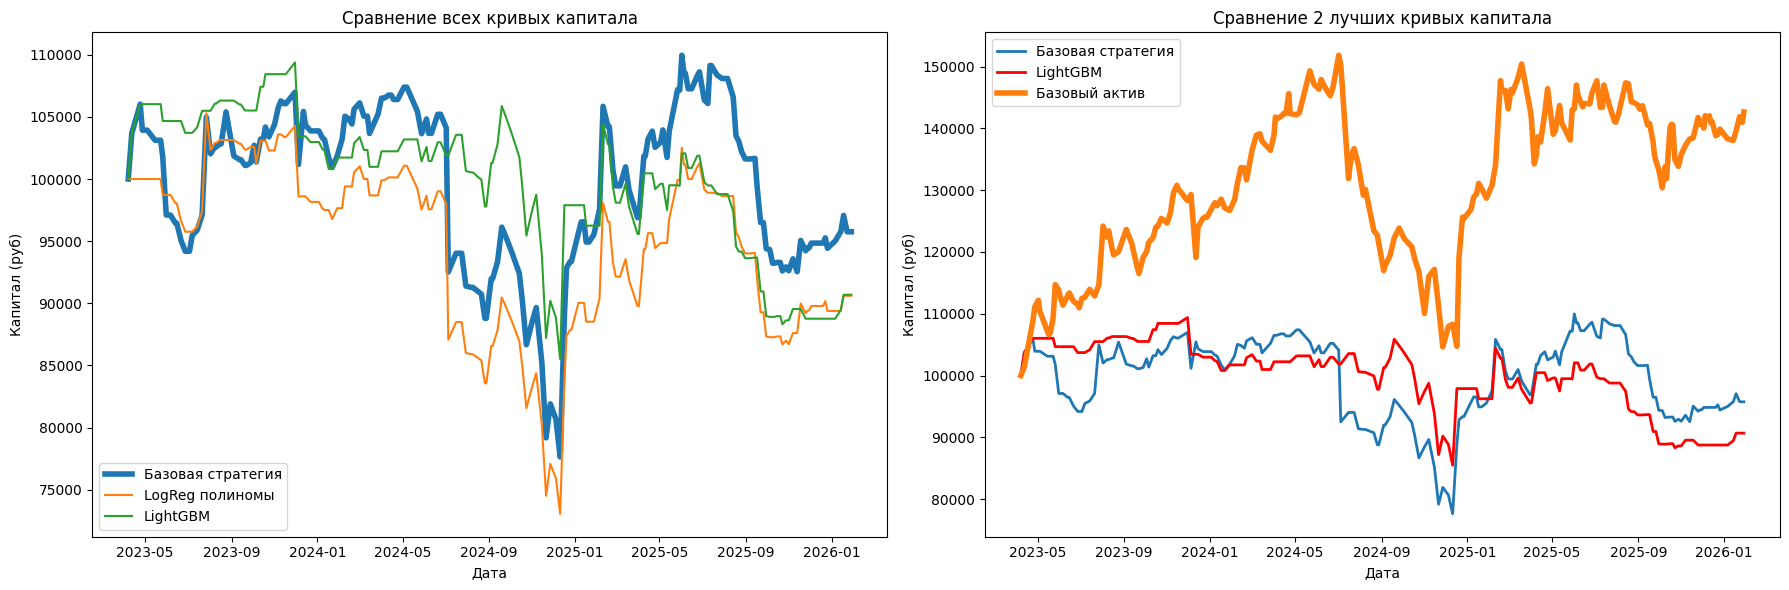

In [170]:
# Обучаем все модели
y_pred_logreg_basic = logreg_basic(X, y, max_features=10)
y_pred_logreg_poly = logreg_poly(X, y, degree=2, max_features=10)
y_pred_lightgbm = lightgbm_small(X, y, max_features=10)
y_pred_tree = decision_tree_small(X, y, max_features=10)
y_pred_rf = random_forest_small(X, y, max_features=10)


# Собираем в словарь
models_pred = {
    'LogReg полиномы': y_pred_logreg_poly,
    'LightGBM': y_pred_lightgbm,

}
# models_pred = {
#     'LogReg базовая': y_pred_logreg_basic,
#     'LogReg полиномы': y_pred_logreg_poly,
#     'LightGBM': y_pred_lightgbm,
#     'Дерево решений': y_pred_tree,
#     'Случайный лес': y_pred_rf
# }
# Визуализация
best1, best2, base = final_result_general(
    data=df_ml,
    models_predictions=models_pred,
    y_test_graph=y_test,
    share=tatneft_graph
)